[*********************100%***********************]  1 of 1 completed


(4082, 5)
2.220446049250313e-16


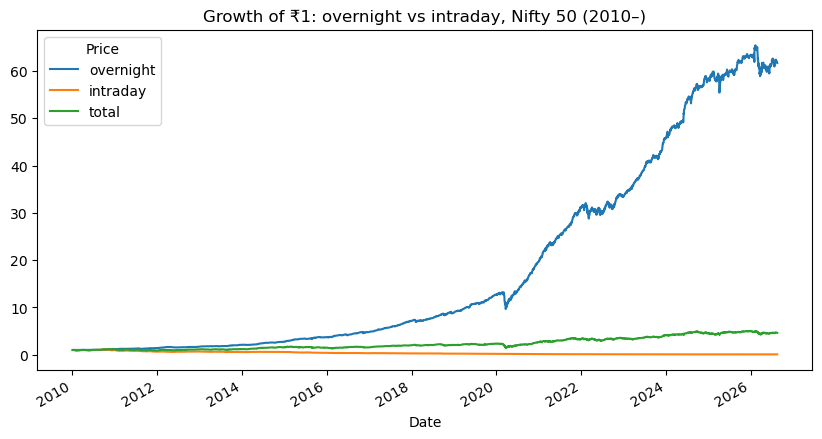

In [2]:
import yfinance as yf
import pandas as pd

df = yf.download("^NSEI", start="2010-01-01")
print(df.shape)
df.head()
df.columns = df.columns.droplevel(1)


df["overnight"] = df["Open"] / df["Close"].shift(1) - 1
df["intraday"] = df["Close"] / df["Open"] - 1
df["total"] = df["Close"] / df["Close"].shift(1) - 1

# sanity check — should be ~1e-15
check = (1 + df["overnight"]) * (1 + df["intraday"]) - 1
print((check - df["total"]).abs().max())

import matplotlib.pyplot as plt
(1 + df[["overnight", "intraday", "total"]].fillna(0)).cumprod().plot(figsize=(10, 5))
plt.title("Growth of ₹1: overnight vs intraday, Nifty 50 (2010–)")
plt.show()

In [4]:
stale = (df["Open"] == df["Close"].shift(1))
print("Exactly stale opens:", stale.sum(), "out of", len(df))

# also catch near-stale: open within 0.01% of previous close
near_stale = (df["overnight"].abs() < 0.0001)
print("Near-zero overnight moves:", near_stale.sum())

Exactly stale opens: 12 out of 4082
Near-zero overnight moves: 161


In [5]:
print("10 biggest overnight gains:")
print(df["overnight"].nlargest(10))
print("\n10 biggest overnight losses:")
print(df["overnight"].nsmallest(10))

10 biggest overnight gains:
Date
2026-02-03    0.048614
2020-04-07    0.044843
2020-05-13    0.042152
2020-04-17    0.036768
2024-06-03    0.035827
2020-03-27    0.035602
2026-04-08    0.031634
2020-03-24    0.031280
2020-03-31    0.029978
2011-10-28    0.028951
Name: overnight, dtype: float64

10 biggest overnight losses:
Date
2020-03-23   -0.091448
2016-11-09   -0.055720
2020-03-13   -0.050317
2025-04-07   -0.050036
2020-03-19   -0.047882
2020-03-12   -0.040011
2020-03-16   -0.036905
2020-06-12   -0.036058
2018-02-06   -0.034819
2011-08-09   -0.033330
Name: overnight, dtype: float64


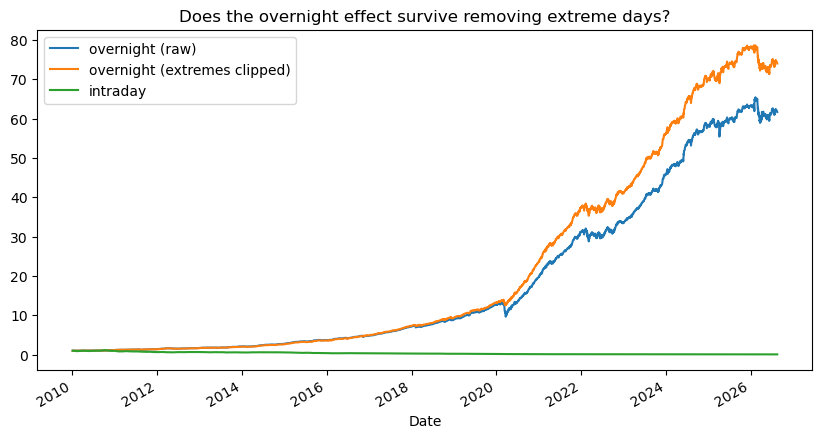

In [6]:
lo, hi = df["overnight"].quantile([0.01, 0.99])
trimmed = df["overnight"].clip(lo, hi)

import matplotlib.pyplot as plt
ax = (1 + df["overnight"].fillna(0)).cumprod().plot(label="overnight (raw)", figsize=(10,5))
(1 + trimmed.fillna(0)).cumprod().plot(ax=ax, label="overnight (extremes clipped)")
(1 + df["intraday"].fillna(0)).cumprod().plot(ax=ax, label="intraday")
ax.legend()
ax.set_title("Does the overnight effect survive removing extreme days?")
plt.show()

In [7]:
import numpy as np

stats = pd.DataFrame({
    "mean (bps/day)": df[["overnight","intraday","total"]].mean() * 1e4,
    "vol (bps/day)": df[["overnight","intraday","total"]].std() * 1e4,
    "ann. return %": df[["overnight","intraday","total"]].mean() * 252 * 100,
    "ann. vol %": df[["overnight","intraday","total"]].std() * np.sqrt(252) * 100,
})
stats["Sharpe-ish"] = stats["ann. return %"] / stats["ann. vol %"]
print(stats.round(2))

# t-test: is the overnight mean statistically distinguishable from zero?
from scipy import stats as sps
t, p = sps.ttest_1samp(df["overnight"].dropna(), 0)
print(f"\nOvernight vs 0: t = {t:.2f}, p = {p:.4f}")
t2, p2 = sps.ttest_1samp(df["intraday"].dropna(), 0)
print(f"Intraday vs 0:  t = {t2:.2f}, p = {p2:.4f}")

           mean (bps/day)  vol (bps/day)  ann. return %  ann. vol %  \
Price                                                                 
overnight           10.29          60.80          25.93        9.65   
intraday            -5.95          86.77         -15.00       13.77   
total                4.29         103.77          10.82       16.47   

           Sharpe-ish  
Price                  
overnight        2.69  
intraday        -1.09  
total            0.66  

Overnight vs 0: t = 10.81, p = 0.0000
Intraday vs 0:  t = -4.38, p = 0.0000
